# Computer Vision (CV)

CV is the process of teaching the model to see.

Types of Tasks:
  - Binary Classification
  - Multiclass Classification
  - Object Detection: Detect the object within the visual (image, video)
  - Segmentation: Segregate the sections of the image (arm, hand, eyes, teeth)

Usual Representation of Image:
  - `Shape = [Batch_Size, Height, Width, ColorChannel]` (Known as Color Channels Last / NHWC)
  - `Shape = [Batch_Size, ColorChannel, Height, Width]` (Known as Color Channels First / NCHW)

PyTorch defaults to CHW/NCHW representation

## Convolutional Neural Network

It's a type of deep learning algorithm primarily used for analyzing visual data, such as images and videos, by mimicking the human visual cortex. CNNs automatically learn to identify hierarchical patterns—from simple edges to complex objects—using specialized layers like convolutional layers for feature extraction, pooling layers for downsampling, and fully connected layers for classification. 

**Architecture of a CNN:**
| Hyperparameter/Layer Type               | What does it do? | Typical Values |
| --------------------------------------- | ---------------- | -------------- |
| Input Image(s)                          | Target Image                 |                |
| Input Layer                             | Takes in Target Images & preprocesses for further layers                 | NHWC or NCHW               |
| Convolution Layer                       | Extracts/learns the most important features from target images                 | Multiple, can create with `torch.nn.ConvXd()` (X can be multiple values)              |
| Hidden Activation/Non-Linear Activation | Adds non-linearity to learned features                 | Usually ReLU `torch.nn.ReLU()`               |
| Pooling Layer                           | Reduces the dimensionality of learned image features                 | Max (`torch.nn.MaxPool2d()`) or Average (`torch.nn.AvgPool2d()`)               |
| Output/Linear Layer                     | Takes learned features and outputs them in shape of target labels                 | `torch.nn.Linear(in_features=n, out_features=Num_classes)`               |
| Output Activation                       | Converts output logits to prediction probability                  | `torch.sigmoid()` for binary classification or `torch.softmax()` for multi-class classification               |

### 0. PyTorch Libraries for CV

- `torchvision` is the base library for CV
- `torchvision.datasets`: get datasets and data loading function for CV
- `torchvision.model`: get pre-trained CV models that can leverage for your own problems
- `torchvision.transforms`: functions for manipulating your vision data to be suitable for models
- `torch.utils.data.Dataset`: Base dataset class for PyTorch
- `torch.utils.data.DataLoader`: Creates a PyTorch iterable over a dataset

In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device, torch.__version__, torchvision.__version__

('cuda', '2.5.0', '0.20.0')

### 1. Getting a dataset

Fashion MNIST dataset- greyscale images of clothing items

In [2]:
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # Do we want the training or testing set 
    download=True, # dow we want to download the dataset
    transform=ToTensor(), # How to transform the data
    target_transform=None # How to transform the labels
)

test_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=False, # Do we want the training or testing set 
    download=True, # dow we want to download the dataset
    transform=ToTensor(), # How to transform the data
    target_transform=None # How to transform the labels
)

In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
# See the training example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_idx = train_data.class_to_idx
class_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [7]:
# Check the Shapes
f"{image.shape=} | C H W", f"{label=}", f"{class_names[label]=}"

('image.shape=torch.Size([1, 28, 28]) | C H W',
 'label=9',
 "class_names[label]='Ankle boot'")

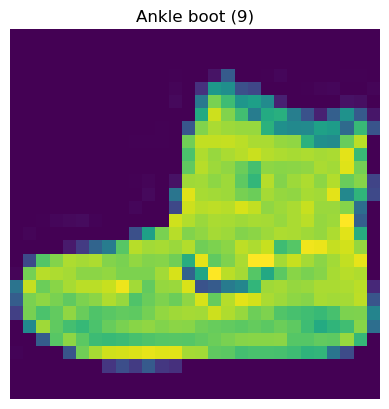

In [8]:
image, label = train_data[0]

plt.imshow(image.squeeze())
plt.title(f"{class_names[label]} ({label})")
plt.axis(False);

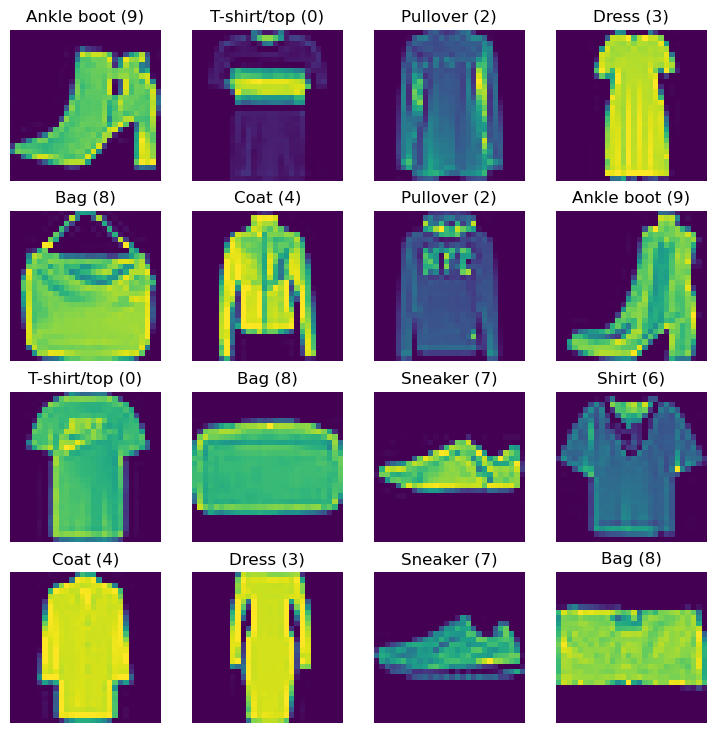

In [9]:
# Plot more images

fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4

for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze())
    plt.title(f"{class_names[label]} ({label})")
    plt.axis(False)

plt.show()

### 2. Prepare DataLoader

Out dataset is rightnow in the form of PyTorch Dataset

In [10]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

DataLoader turns out dataset into a Python iterable.

More specifically, we turn our data into batches (mini-batches).

Reasons for this doing this:
- It's more computationally efficient. Our computing h/w might not be able to look at (store in memory) 60000 images in one hit. So we break it down to 32 images at a time.
- It gives out NN more chances to update its gradients per epoch.

In [11]:
from torch.utils.data import DataLoader

# Hyperparameter batch size
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x2b995c71e40>,
 <torch.utils.data.dataloader.DataLoader at 0x2b995c72140>)

In [12]:
len(train_dataloader), len(test_dataloader)

(1875, 313)

In [13]:
# check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))

train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

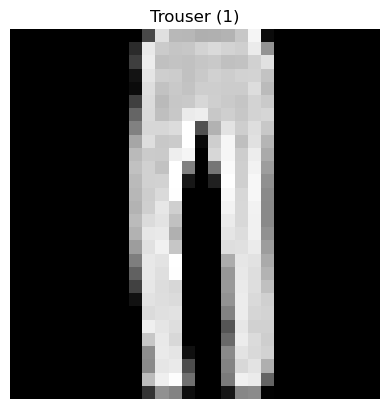

In [14]:
# A sample
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()

img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"{class_names[label]} ({label})")
plt.axis(False);

### 3. Model-0: Baseline Model

A baseline model is a simple model you would try to update & improve with subsequent models/experiments

In short, Start Simple and add Complexities when necessary

In [15]:
# Create a Flatten Model

flatten_model = nn.Flatten()

x = train_features_batch[0]

y = flatten_model(x)
print(f"Shape Before Flattening: {x.shape}")
print(f"Shape After Flattening: {y.shape}")

Shape Before Flattening: torch.Size([1, 28, 28])
Shape After Flattening: torch.Size([1, 784])


In [16]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [17]:
model0 = FashionMNISTModelV0(input_shape=784, hidden_units=10, output_shape=len(class_idx)).to("cpu")
model0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [18]:
dummy_x = torch.rand([1, 1, 28, 28])
y_logits = model0(dummy_x)
y_probs = torch.softmax(y_logits, dim=1)
y_preds = torch.argmax(y_probs, dim=1)
y_label = class_names[y_preds.item()]

# Since softmax doesn't change the ranking we can simply use argmax
y_preds_without_softmax = y_logits.argmax(dim=1)
y_label_without_softmax = class_names[y_preds_without_softmax.item()]


print(y_logits, y_probs, y_preds, y_label, sep="\n\n")
print("\n\n\n", y_preds_without_softmax, y_label_without_softmax, sep="\n\n")

tensor([[-0.3700,  0.2062, -0.3401,  0.5332,  0.2674,  0.0161,  0.3642,  0.1192,
          0.2150,  0.2394]], grad_fn=<AddmmBackward0>)

tensor([[0.0589, 0.1047, 0.0606, 0.1452, 0.1113, 0.0866, 0.1227, 0.0960, 0.1057,
         0.1083]], grad_fn=<SoftmaxBackward0>)

tensor([3])

Dress





tensor([3])

Dress


In [19]:
 model0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0104,  0.0252,  0.0050,  ..., -0.0330,  0.0048, -0.0133],
                      [-0.0165, -0.0198, -0.0052,  ...,  0.0282,  0.0102,  0.0302],
                      [ 0.0344, -0.0058, -0.0267,  ...,  0.0198, -0.0180,  0.0185],
                      ...,
                      [-0.0182,  0.0021,  0.0177,  ..., -0.0313,  0.0325,  0.0207],
                      [-0.0027, -0.0327,  0.0278,  ..., -0.0167,  0.0107,  0.0291],
                      [ 0.0282,  0.0249,  0.0141,  ...,  0.0321, -0.0182,  0.0030]])),
             ('layer_stack.1.bias',
              tensor([-0.0153,  0.0120, -0.0338,  0.0114, -0.0050, -0.0290,  0.0265,  0.0099,
                       0.0123, -0.0287])),
             ('layer_stack.2.weight',
              tensor([[-0.0717,  0.1638, -0.1114, -0.2811,  0.0682, -0.0657,  0.2674, -0.1955,
                        0.0202,  0.2252],
                      [-0.2585, -0.1843,  0.2840,  0.1579, -0.1073, -0.0217,  0.

### 3.1 Setup loos function, optimizer & evaluation metrics

* Loss Function: since the task is multi-class classification, our loss will be `nn.CrossEntropyLoss()`
* Optimizer: `torch.optim.SGD()`
* Metrics: `torchmetrics.classification.Accuracy`

In [20]:
from torchmetrics.classification import Accuracy, Precision, Recall, F1Score

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model0.parameters(), lr=0.01)
acc_fn = Accuracy(task="multiclass", num_classes=10)
# pcs_fn = Precision(task="multiclass", num_classes=10)
# rcl_fn = Recall(task="multiclass", num_classes=10)
# f1_fn = F1Score(task="multiclass", num_classes=10)

loss_fn, optimizer, acc_fn#, pcs_fn, rcl_fn, f1_fn

(CrossEntropyLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ),
 MulticlassAccuracy())

### 3.2 Creating a function to time our experiments

Two of the main things you'll often want to track are:
- Model's Performance (loss & accuracy values, etc.)
- How fat it runs (inference time)

In [21]:
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [22]:
start_time = timer()
for _ in range(100_000):
    ...
end_time = timer()

print_train_time(start_time, end_time, "cpu")

Train time on cpu: 0.009 seconds


0.008658000035211444

### 3.3 Create a training loop & train on batches of data

Using batches means that the optimizer will update the parameters once per batch rather than once per epoch

1. Loop Epochs:
    1. Loop Batches:
        1. Set Model to Train
        2. Feed-Forward
        3. Calculate Loss
        4. Zero Grad
        5. Backpropagation
        6. Optimize / Gradient Descent
        7. Measure performance using Metrics like Time, Accuracy, etc

In [23]:
from tqdm.auto import tqdm # for progress bar

# start timer
start_time = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-----------------")
    # Training
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(train_dataloader):
        model0.train()
        y_logits = model0(X)
        # y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
        y_preds = y_logits.argmax(dim=1)

        loss = loss_fn(y_logits, y)
        train_loss += loss.item()
        train_acc += acc_fn(y_preds, y).item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % int(len(train_dataloader) * 0.2) == 0:
            print(f"Looked at {batch * len(X)} / {len(train_dataloader.dataset)} samples.")

    # Divide total train loss by length of train dataloader
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    # Testing
    test_loss, test_acc = 0, 0
    model0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            y_logits = model0(X)
            # y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
            y_preds = y_logits.argmax(dim=1)
            test_loss += loss_fn(y_logits, y).item()
            test_acc += acc_fn(y_preds, y).item()

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\n Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

end_time = timer()
model0_train_time = print_train_time(start=start_time, end=end_time, device="cpu");

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----------------
Looked at 0 / 60000 samples.
Looked at 12000 / 60000 samples.
Looked at 24000 / 60000 samples.
Looked at 36000 / 60000 samples.
Looked at 48000 / 60000 samples.

 Train Loss: 0.8894 | Train Accuracy: 0.7077 | Test Loss: 0.6456 | Test Accuracy: 0.7775
Epoch: 1
-----------------
Looked at 0 / 60000 samples.
Looked at 12000 / 60000 samples.
Looked at 24000 / 60000 samples.
Looked at 36000 / 60000 samples.
Looked at 48000 / 60000 samples.

 Train Loss: 0.5664 | Train Accuracy: 0.8096 | Test Loss: 0.5487 | Test Accuracy: 0.8092
Epoch: 2
-----------------
Looked at 0 / 60000 samples.
Looked at 12000 / 60000 samples.
Looked at 24000 / 60000 samples.
Looked at 36000 / 60000 samples.
Looked at 48000 / 60000 samples.

 Train Loss: 0.5025 | Train Accuracy: 0.8279 | Test Loss: 0.5204 | Test Accuracy: 0.8152
Train time on cpu: 121.070 seconds


### 4. make predictions and get results

In [24]:
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               acc_fn: Accuracy,
               device: torch.device = "cpu"
              ):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X = X.to(device)
            y = y.to(device)
            y_logits = model(X)
            y_preds = y_logits.argmax(dim=1)
            loss += loss_fn(y_logits, y).item()
            acc += acc_fn(y_preds, y).item()
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss,
        "model_acc": acc
    }

In [25]:
model0_results = eval_model(model0, test_dataloader, loss_fn, acc_fn)
model0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5203689901402202,
 'model_acc': 0.8151956869009584}

### 5. setup device agnostic code & build a better model with Non-Linearity

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [27]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_features, hidden_units, output_features):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.layer_stack(x)

In [28]:
model1 = FashionMNISTModelV1(input_features=28*28, hidden_units=10, output_features=len(class_names)).to(device)
model1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [29]:
next(model1.parameters()).device

device(type='cuda', index=0)

In [30]:
loss_fn =nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model1.parameters(), lr=0.1)
acc_fn = Accuracy(task="multiclass", num_classes=len(class_names)).to(device)

In [31]:
def train_step(model, train_dataloader, loss_fn, acc_fn, optimizer, device):
    model.to(device)
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(train_dataloader):
        X = X.to(device)
        y = y.to(device)
        
        model.train()
        y_logits = model(X)
        y_preds = y_logits.argmax(dim=1)

        loss = loss_fn(y_logits, y)
        train_loss += loss.item()
        train_acc += acc_fn(y_preds, y).item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % int(len(train_dataloader) * 0.2) == 0:
            print(f"Looked at {batch * len(X)} / {len(train_dataloader.dataset)} samples")
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)
    print(f"\t\tTrain Loss: {test_loss} | Train Accuracy: {test_acc}")

In [32]:
def test_step(model, test_dataloader, loss_fn, acc_fn, device):
    model.to(device)
    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for (X, y) in test_dataloader:
            X = X.to(device)
            y = y.to(device)
        
            y_logits = model(X)
            y_preds = y_logits.argmax(dim=1)

            test_loss += loss_fn(y_logits, y).to(device)
            test_acc += acc_fn(y_preds, y).to(device)
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    print(f"\t\tTest Loss: {test_loss} | Test Accuracy: {test_acc} \n\n")

In [33]:
epochs = 3

start_time = timer()
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}")
    train_step(model1, train_dataloader, loss_fn, acc_fn, optimizer, device)
    test_step(model1, test_dataloader, loss_fn, acc_fn, device)
end_time = timer()
model1_train_time = print_train_time(start_time, end_time, device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
Looked at 0 / 60000 samples
Looked at 12000 / 60000 samples
Looked at 24000 / 60000 samples
Looked at 36000 / 60000 samples
Looked at 48000 / 60000 samples
		Train Loss: 0.5203689901402202 | Train Accuracy: 0.8151956869009584
		Test Loss: 0.5698944926261902 | Test Accuracy: 0.7964257001876831 


Epoch: 1
Looked at 0 / 60000 samples
Looked at 12000 / 60000 samples
Looked at 24000 / 60000 samples
Looked at 36000 / 60000 samples
Looked at 48000 / 60000 samples
		Train Loss: 0.5203689901402202 | Train Accuracy: 0.8151956869009584
		Test Loss: 0.4831462800502777 | Test Accuracy: 0.8244808316230774 


Epoch: 2
Looked at 0 / 60000 samples
Looked at 12000 / 60000 samples
Looked at 24000 / 60000 samples
Looked at 36000 / 60000 samples
Looked at 48000 / 60000 samples
		Train Loss: 0.5203689901402202 | Train Accuracy: 0.8151956869009584
		Test Loss: 0.47512954473495483 | Test Accuracy: 0.8336661458015442 


Train time on cuda: 120.972 seconds


In [34]:
model1_results = eval_model(model1.to("cpu"), test_dataloader, loss_fn, acc_fn)
model1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.4751296784169377,
 'model_acc': 0.8336661341853036}

**Note:** Sometimes, depending on our data and hardware we might find that the model trains faster on CPU than on GPU.

Why?
- It could be that the overhead of copying data/model to and from the CPU outweighs the compute benefits offered by the GPU.
- The hardware you're using has a better CPU in terms of compute capabilities than the GPU.

## Model-2: CNN

CNNs are also known as **ConvNets**. They are known for their capabilities to find patterns in Visual Data.

In [35]:
class FashionMNISTv2(nn.Module):
    def __init__(self, input_shape: int, out_shape:int, hidden_units: int):
        super().__init__()
        # Feature Extraction
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        # Classification
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=(hidden_units*7*7), out_features=out_shape)
        )
    def forward(self, x):
        z = self.conv_block_1(x)
        # print(f"Conv-1: {z.shape}")
        z = self.conv_block_2(z)
        # print(f"Conv-2: {z.shape}")
        z = self.classifier(z)
        # print(f"Classifier: {z.shape}")
        return z

In [36]:
model2 = FashionMNISTv2(input_shape=1, hidden_units=10, out_shape=len(class_names)).to(device)
model2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.2893, -0.3217,  0.2641],
                        [-0.0243, -0.0121,  0.0181],
                        [ 0.0399, -0.2135, -0.2828]]],
              
              
                      [[[ 0.1751,  0.0019,  0.1303],
                        [ 0.1871, -0.1822,  0.3071],
                        [-0.0205,  0.2289,  0.0080]]],
              
              
                      [[[-0.0504, -0.2336,  0.2341],
                        [ 0.3278,  0.0390, -0.3141],
                        [ 0.1744, -0.1495, -0.2560]]],
              
              
                      [[[ 0.1769,  0.2825,  0.3025],
                        [-0.2381, -0.1758,  0.2316],
                        [ 0.2627, -0.1745,  0.1439]]],
              
              
                      [[[ 0.1384,  0.2200,  0.1914],
                        [-0.0820, -0.2470, -0.0192],
                        [-0.2668, -0.2851, -0.0179]]],
              
              
      

In [37]:
next(model2.parameters()).device

device(type='cuda', index=0)

### Stepping through `nn.Conv2d`

In [38]:
import numpy as np
def visualize(image, rows=1, cols=1, idx=1):
        plt.subplot(rows, cols, idx)
        plt.imshow(np.transpose(image, (1, 2, 0)))
        plt.axis(False)
        idx += 1

In [39]:
# Create a batch of images
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single Image shape: {test_image.shape}")
print(f"Test I|mage: {test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single Image shape: torch.Size([3, 64, 64])
Test I|mage: tensor([[[ 0.3796, -0.2880,  0.8154,  ...,  0.8142, -1.0038,  0.5741],
         [-0.0837, -0.4554,  0.2113,  ..., -0.4787, -1.4963, -1.6586],
         [-0.8013,  2.0950, -1.0860,  ..., -0.6827,  0.7571,  0.1761],
         ...,
         [ 1.1684,  0.0451,  0.2724,  ..., -0.3373,  2.4390, -0.8196],
         [ 0.0607,  0.7674,  0.5299,  ...,  0.3675, -2.6634, -0.2100],
         [-0.7001,  0.9997, -0.1193,  ...,  1.9377,  0.3970,  0.6415]],

        [[ 0.5480, -0.3216,  0.2297,  ...,  1.5821,  0.7092, -0.4558],
         [-1.6745, -1.2371, -1.2997,  ..., -1.9819, -1.1817,  0.4452],
         [-1.1587,  0.4264,  2.7820,  ..., -0.9848, -1.4155, -0.8055],
         ...,
         [-0.5884, -0.8810, -1.7856,  ...,  1.5157,  0.7920,  0.0095],
         [ 2.0614,  0.4002,  2.0073,  ...,  0.5283, -0.7431, -0.2184],
         [ 0.1129, -1.2719, -0.0229,  ...,  0.0829,  0.2464, -2.1926]],

        [[ 1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.773875..3.745525].


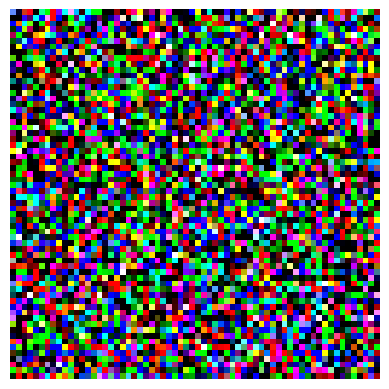

In [40]:
visualize(test_image)

In [41]:
# Create a single Conv2d Layer
conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=(3, 3),
    stride=1,
    padding=0
)

In [42]:
conv_output = conv_layer(test_image)
conv_output, conv_output.shape

(tensor([[[ 0.6542, -0.6924,  0.0753,  ...,  0.7133, -0.2247, -0.6295],
          [ 0.8152,  0.1772, -0.4215,  ...,  0.4661, -0.3424,  0.4398],
          [-0.4747,  1.3387, -0.1357,  ...,  0.3426,  0.7846,  0.8578],
          ...,
          [ 0.1786, -0.8124,  0.4354,  ...,  0.9938,  1.1753,  0.2273],
          [ 0.5567, -0.0807,  0.8628,  ..., -0.5826, -0.0521,  0.7116],
          [-0.0082, -0.6272, -0.1356,  ...,  1.0522, -0.3402, -1.0687]],
 
         [[ 0.1115, -0.3678, -0.6343,  ..., -0.6193,  0.8909,  0.5490],
          [-1.2950, -0.0930,  0.4903,  ...,  1.1102, -0.3391,  0.1376],
          [-0.4672, -0.2549,  0.8805,  ..., -0.9937,  0.8913, -0.4650],
          ...,
          [ 0.7073,  0.1864, -0.4913,  ..., -1.7314, -0.0307,  0.3370],
          [ 0.1565,  0.0501, -0.1942,  ...,  0.6062, -0.6429, -0.5985],
          [-0.1197,  0.3934, -0.1014,  ..., -0.2033,  0.9936,  0.1513]],
 
         [[-0.3897,  0.7040,  0.2002,  ..., -0.4788, -0.3962,  0.0910],
          [-0.8139, -0.1929,

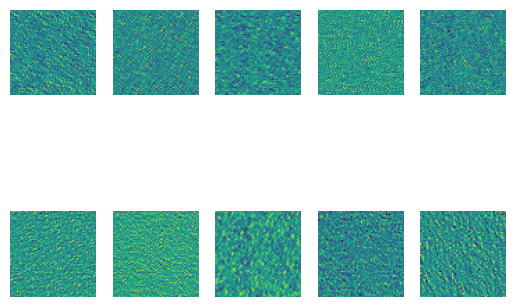

In [43]:
for idx, img in enumerate(conv_output):
    visualize(img.unsqueeze(0).detach(), rows=2, cols=5, idx=idx+1)

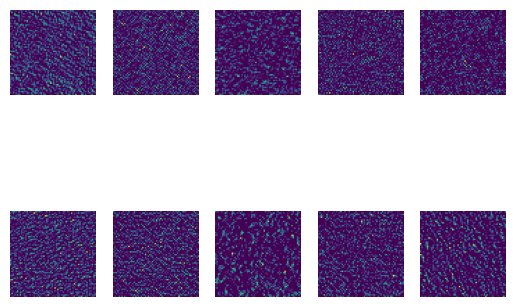

In [44]:
relu = nn.ReLU()
relu_output = relu(conv_output)
for idx, img in enumerate(relu_output):
    visualize(img.unsqueeze(0).detach(), rows=2, cols=5, idx=idx+1)

In [45]:
conv_layer2 = nn.Conv2d(
    in_channels=10,
    out_channels=10,
    kernel_size=(3, 3),
    stride=1,
    padding=0
)
conv_output2 = conv_layer2(relu_output)
conv_output2, conv_output2.shape

(tensor([[[-0.1728, -0.2986, -0.1223,  ..., -0.1473, -0.1284, -0.2978],
          [ 0.0093, -0.3507,  0.1879,  ..., -0.1093, -0.3946, -0.3102],
          [-0.5858, -0.0633,  0.1325,  ..., -0.2316, -0.4840, -0.5707],
          ...,
          [-0.2901, -0.2612, -0.2251,  ..., -0.3484,  0.1359, -0.4128],
          [-0.3938, -0.0809, -0.1564,  ..., -0.0973, -0.7998, -0.0504],
          [-0.0708,  0.0416, -0.4521,  ..., -0.2815, -0.0334, -0.7072]],
 
         [[-0.3262,  0.1026,  0.3448,  ...,  0.0841, -0.1907, -0.0165],
          [-0.1555, -0.0598, -0.0629,  ..., -0.0065,  0.2100, -0.2683],
          [ 0.3689,  0.0331, -0.2718,  ..., -0.3653,  0.2545,  0.3037],
          ...,
          [-0.2238,  0.3437, -0.0691,  ...,  0.3834, -0.4150,  0.0702],
          [ 0.1553,  0.1263,  0.1335,  ...,  0.2732,  0.2470, -0.2721],
          [ 0.1639, -0.2172, -0.0795,  ...,  0.1727, -0.4444, -0.0338]],
 
         [[ 0.1408, -0.2710,  0.2732,  ...,  0.5832,  0.1208,  0.1140],
          [ 0.4695, -0.1521,

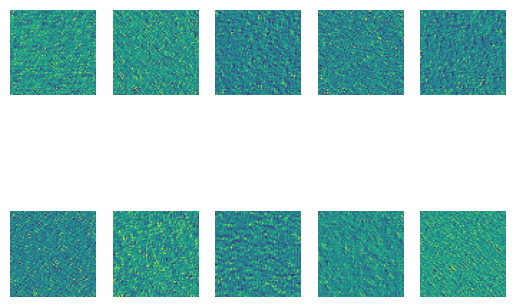

In [46]:
for idx, img in enumerate(conv_output2):
    visualize(img.unsqueeze(0).detach(), rows=2, cols=5, idx=idx+1)

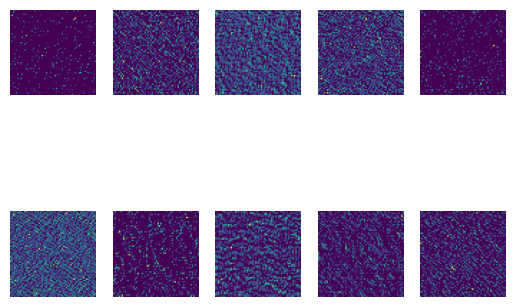

In [47]:
relu_output2 = relu(conv_output2)
for idx, img in enumerate(relu_output2):
    visualize(img.unsqueeze(0).detach(), rows=2, cols=5, idx=idx+1)

In [48]:
max_pool = nn.MaxPool2d(kernel_size=2)
max_output = max_pool(relu_output2)
max_output, max_output.shape

(tensor([[[0.0093, 0.2005, 0.0401,  ..., 0.0088, 0.0000, 0.0000],
          [0.0000, 0.1325, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.3285, 0.0000, 0.0332,  ..., 0.0000, 0.0158, 0.0240],
          ...,
          [0.0000, 0.0940, 0.1398,  ..., 0.0090, 0.0029, 0.0000],
          [0.0000, 0.0021, 0.0000,  ..., 0.0161, 0.0000, 0.1359],
          [0.0416, 0.0000, 0.1697,  ..., 0.0230, 0.0000, 0.0000]],
 
         [[0.1026, 0.3448, 0.2558,  ..., 0.1436, 0.0841, 0.2100],
          [0.3689, 0.2070, 0.1394,  ..., 0.2345, 0.0000, 0.3037],
          [0.1643, 0.2016, 0.1486,  ..., 0.1839, 0.1726, 0.1372],
          ...,
          [0.2871, 0.2038, 0.1360,  ..., 0.3538, 0.1594, 0.1059],
          [0.3437, 0.0174, 0.2333,  ..., 0.3010, 0.3834, 0.0702],
          [0.1639, 0.1812, 0.1431,  ..., 0.1838, 0.2732, 0.2470]],
 
         [[0.4695, 0.3144, 0.5611,  ..., 0.1880, 0.5832, 0.5309],
          [0.7044, 0.3235, 0.4588,  ..., 0.3528, 0.5672, 0.2698],
          [0.4207, 0.2097, 0.3324,  ...,

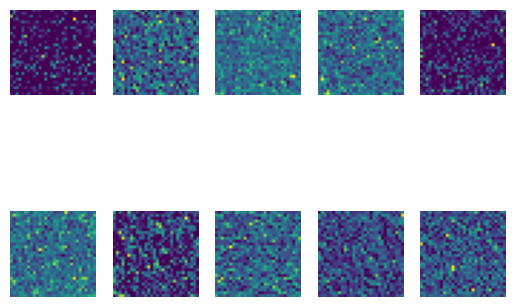

In [49]:
for idx, img in enumerate(max_output):
    visualize(img.unsqueeze(0).detach(), rows=2, cols=5, idx=idx+1)

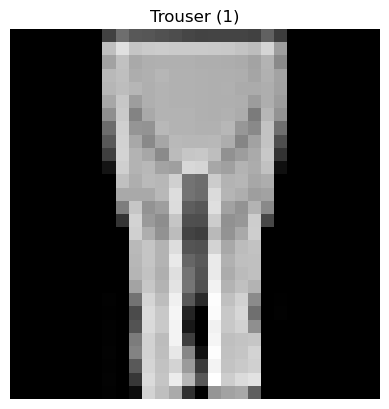

In [50]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))

random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()

img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"{class_names[label]} ({label})")
plt.axis(False);

In [51]:
img.shape

torch.Size([1, 28, 28])

In [52]:
y_probs = model2(img.unsqueeze(0).to(device))
y_label = y_probs.argmax(1).item()

print(f"{y_probs=} | {y_label=} | {label=}")

y_probs=tensor([[ 0.1391,  0.0129,  0.0531, -0.0632,  0.0751, -0.0567, -0.0264,  0.0400,
         -0.0024, -0.1189]], device='cuda:0', grad_fn=<AddmmBackward0>) | y_label=0 | label=tensor(1)


In [53]:
### Setup Loss & Optimizer

loss = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model2.parameters(), lr=0.1)

In [54]:
epochs = 3

start_time = timer()
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}")
    train_step(model2, train_dataloader, loss, acc_fn, optimizer, device)
    test_step(model2, test_dataloader, loss, acc_fn, device)
end_time = timer()
model2_train_time = print_train_time(start_time, end_time, device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
Looked at 0 / 60000 samples
Looked at 12000 / 60000 samples
Looked at 24000 / 60000 samples
Looked at 36000 / 60000 samples
Looked at 48000 / 60000 samples
		Train Loss: 0.5203689901402202 | Train Accuracy: 0.8151956869009584
		Test Loss: 0.41833949089050293 | Test Accuracy: 0.851138174533844 


Epoch: 1
Looked at 0 / 60000 samples
Looked at 12000 / 60000 samples
Looked at 24000 / 60000 samples
Looked at 36000 / 60000 samples
Looked at 48000 / 60000 samples
		Train Loss: 0.5203689901402202 | Train Accuracy: 0.8151956869009584
		Test Loss: 0.36715325713157654 | Test Accuracy: 0.8638178706169128 


Epoch: 2
Looked at 0 / 60000 samples
Looked at 12000 / 60000 samples
Looked at 24000 / 60000 samples
Looked at 36000 / 60000 samples
Looked at 48000 / 60000 samples
		Train Loss: 0.5203689901402202 | Train Accuracy: 0.8151956869009584
		Test Loss: 0.33209049701690674 | Test Accuracy: 0.8766972422599792 


Train time on cuda: 68.746 seconds


In [55]:
model2_results = eval_model(model2, test_dataloader, loss, acc_fn, device)
model2_results

{'model_name': 'FashionMNISTv2',
 'model_loss': 0.3320904913337562,
 'model_acc': 0.8766972843450479}

# Compare Model Results

In [56]:
import pandas as pd

compare_results = pd.DataFrame([model0_results, model1_results, model2_results])
compare_results["training_time"] = [
    model0_train_time,
    model1_train_time,
    model2_train_time,
]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.520369,0.815196,121.070005
1,FashionMNISTModelV1,0.475130,0.833666,120.971992
2,FashionMNISTv2,0.332090,0.876697,68.746083


Text(0, 0.5, 'Model')

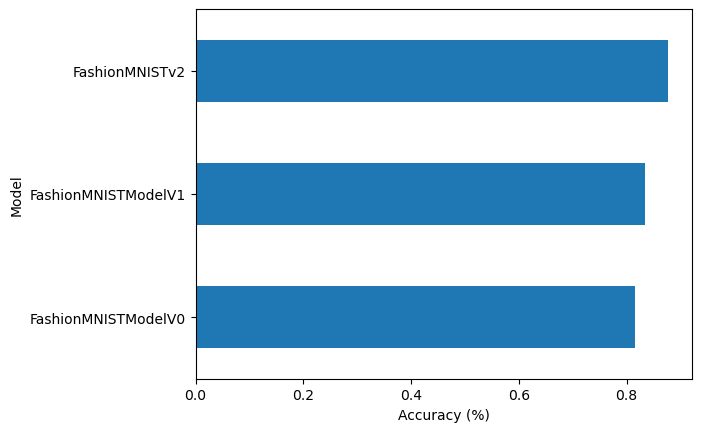

In [57]:
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")

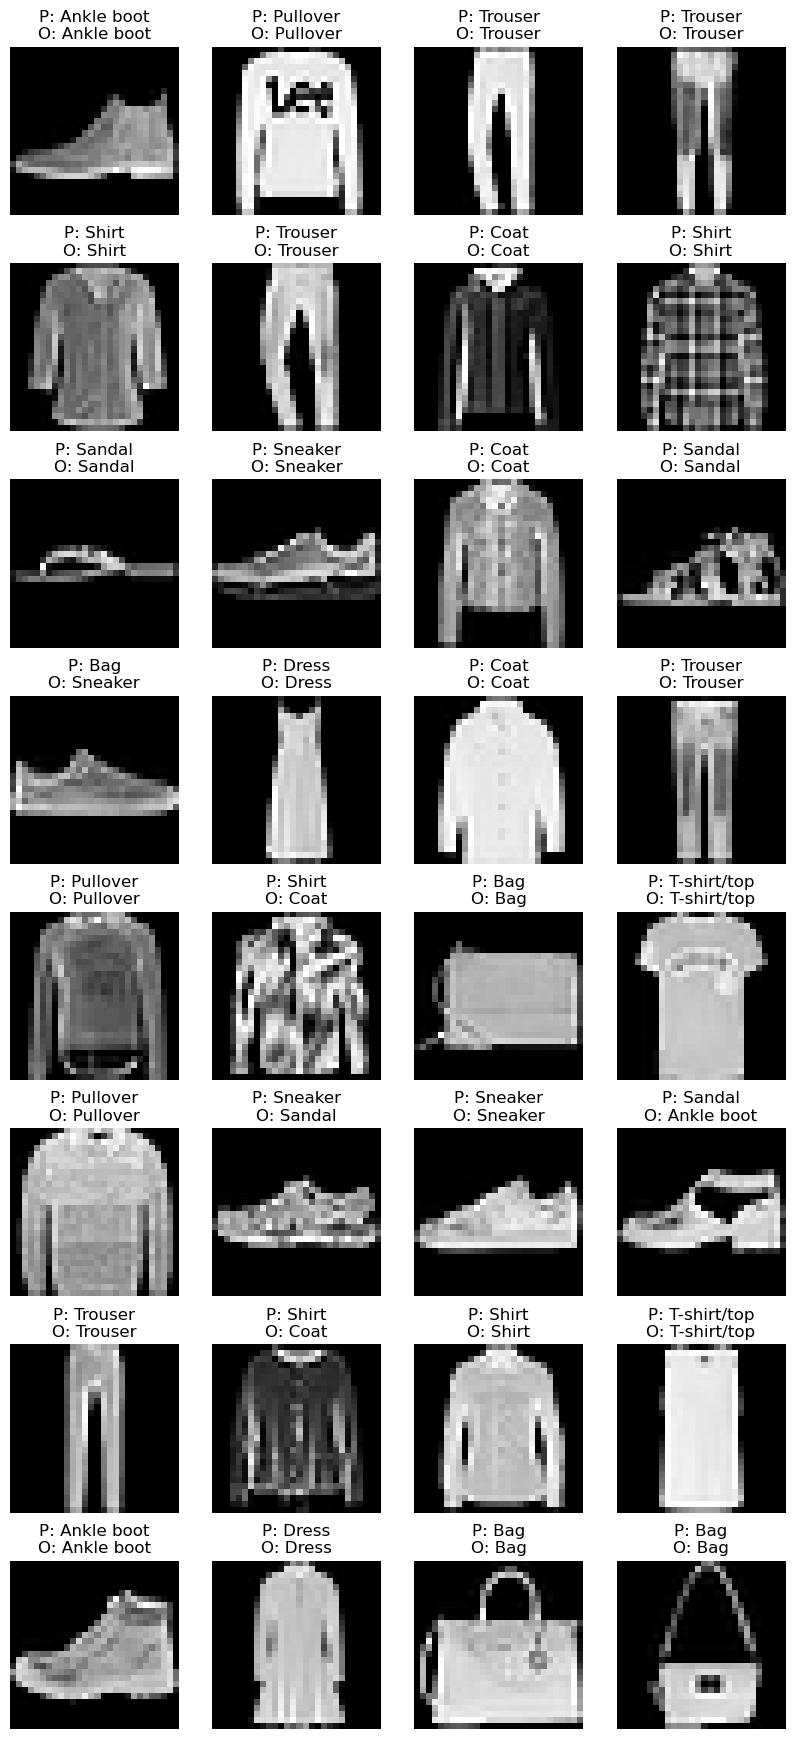

In [58]:
data, labels = next(iter(test_dataloader))
data = data.to(device)
labels = labels.to(device)

with torch.inference_mode():
    y_preds = model2(data)
    y_labels = y_preds.argmax(1)

plt.figure(figsize=(10, 22))
for i, img in enumerate(data):
    plt.subplot(8, 4, i+1)
    plt.imshow(img.squeeze().to("cpu"), cmap="gray")
    plt.axis(False)
    plt.title(f"P: {class_names[y_labels[i]]}\nO: {class_names[labels[i]]}")

In [59]:
def make_predictions(
    model: nn.Module,
    data: list,
    device: torch.device = device
):
    pred_probs = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare Sample: add a batch dimension and pass to the device
            sample = torch.unsqueeze(sample, dim=0).to(device)
            # forward pass
            pred_logits = model(sample)
            # Logit -> Probability
            pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)
            # Get pred_prob off the GPU for further calculations
            pred_probs.append(pred_prob.cpu())
    # Stack pred_probs to turn the list into tensor
    return torch.stack(pred_probs)

In [60]:
image, label = test_data[0][:2]
image.shape, label

(torch.Size([1, 28, 28]), 9)

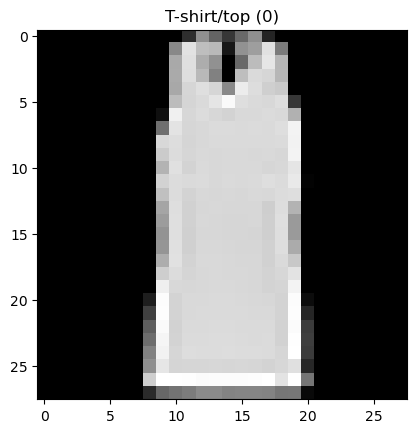

In [61]:
import random
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=20):
    test_samples.append(sample)
    test_labels.append(label)

# view first sample
plt.imshow(test_samples[0].squeeze(), cmap='grey')
plt.title(f"{class_names[test_labels[0]]} ({test_labels[0]})");

In [62]:
# Make Predictions
pred_probs = make_predictions(model=model2, data=test_samples)
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([3, 5, 0, 6, 1, 8, 5, 2, 5, 6, 7, 4, 9, 3, 3, 0, 4, 4, 5, 0])

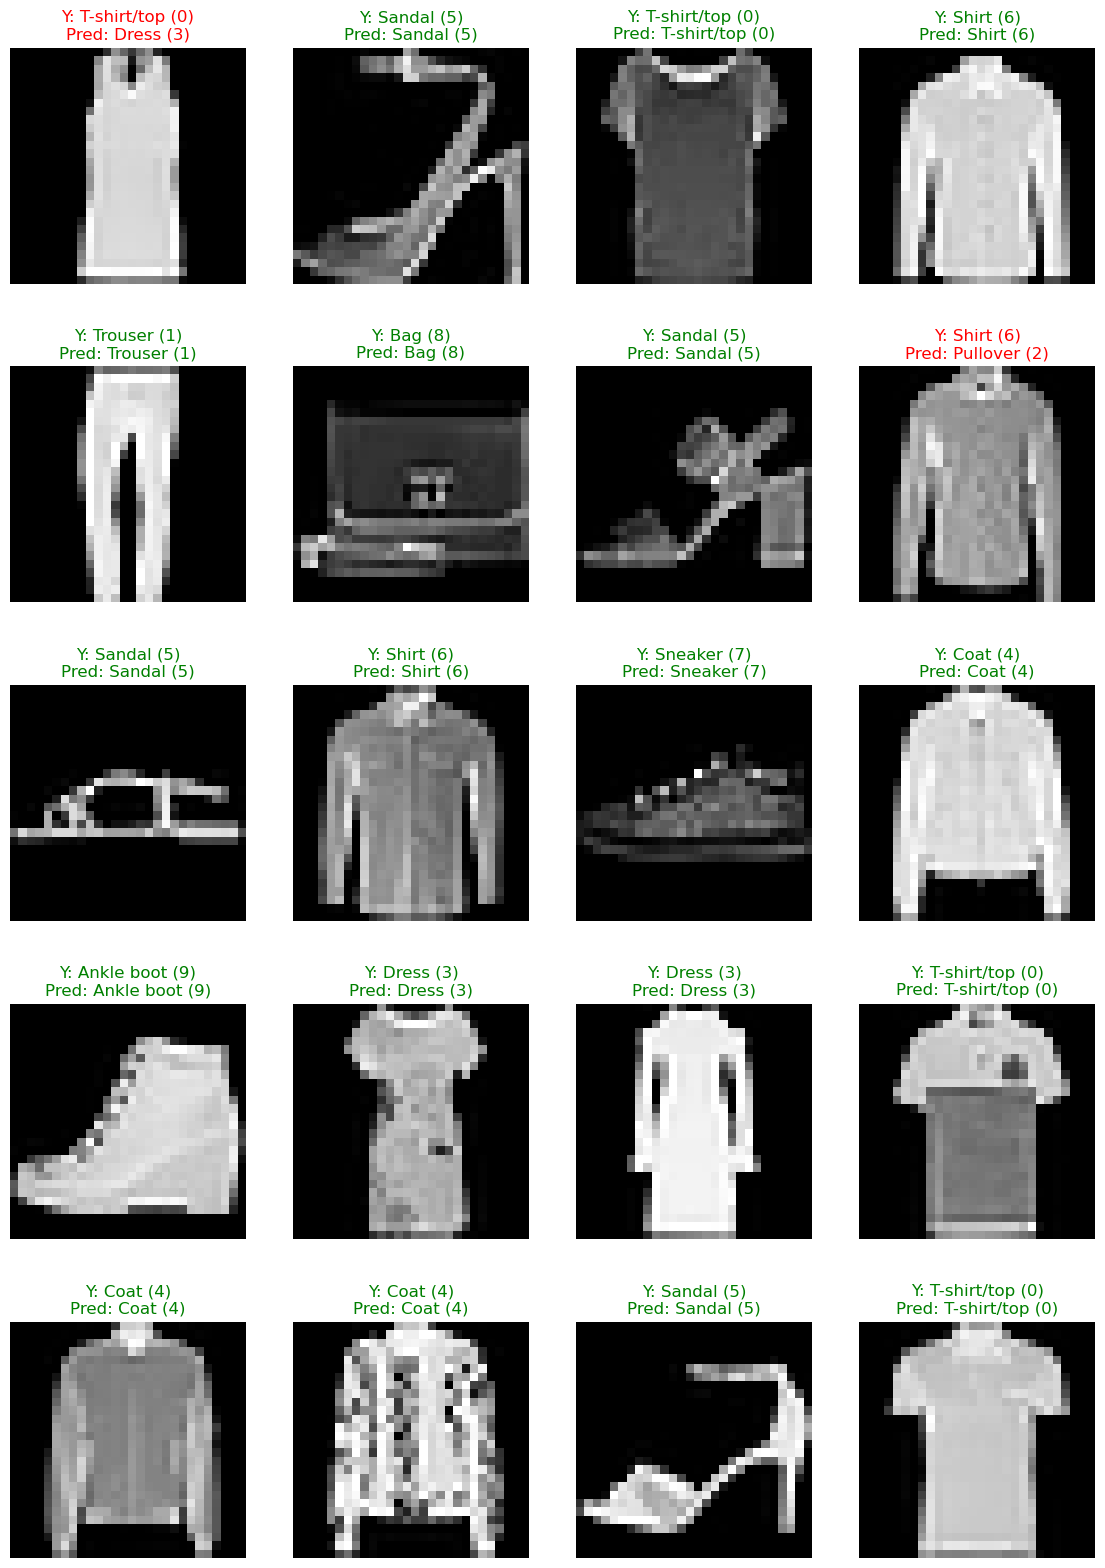

In [63]:
import math

n = len(test_samples)
cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(cols*3.5, rows * 4))
for i, img in enumerate(test_samples):
    y_class = test_labels[i]
    y_label = class_names[y_class]
    pred_class = pred_classes[i]
    pred_label = class_names[pred_class]

    title_color = "g" if y_class == pred_class else "r"
    
    plt.subplot(rows, cols, i+1)
    plt.imshow(img.squeeze(), cmap='grey')
    plt.title(f"Y: {y_label} ({y_class})\nPred: {pred_label} ({pred_class})", c=title_color)
    plt.axis(False);

## Making a Confusion Matrix

1. Make Predictions with our trained model
2. Make a Confusion Matrix using `torchmetrics.ConfusionMatrix`
3.  Plot the confusion matrix using `mlxtend.plotting.plot_confusion_matrix()`

In [64]:
from tqdm.auto import tqdm

# Make Predictions
y_preds = []
model2.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making Predictions...."):
        X, y = X.to(device), y.to(device)
        y_logit = model2(X)
        y_prob = y_logit.squeeze().softmax(dim=0)
        y_pred = y_prob.argmax(dim=1)
        y_preds.append(y_pred.cpu())

y_preds = torch.cat(y_preds)
y_preds[:15], len(y_preds)

Making Predictions....:   0%|          | 0/313 [00:00<?, ?it/s]

(tensor([9, 2, 1, 1, 6, 3, 4, 6, 5, 7, 4, 5, 8, 3, 4]), 10000)

In [65]:
import mlxtend
import torchmetrics

print(f"{mlxtend.__version__=}\n{torchmetrics.__version__=}")

mlxtend.__version__='0.23.4'
torchmetrics.__version__='1.8.2'


In [66]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(
    preds=y_preds,
    target=test_data.targets
)
confmat_tensor

tensor([[704,   5,  13,  74,   8,   1, 188,   0,   7,   0],
        [  5, 883,   7,  68,  28,   1,   3,   1,   4,   0],
        [ 17,   3, 715,  17, 158,   0,  86,   0,   4,   0],
        [ 19,  10,   4, 895,  31,   0,  32,   0,   7,   2],
        [  6,   8,  87,  51, 750,   0,  93,   0,   5,   0],
        [  6,   1,   1,   5,   0, 828,   7,  61,  68,  23],
        [109,   4,  76,  63, 104,   1, 632,   0,  11,   0],
        [  0,   2,   0,   2,   0,  28,   0, 915,  16,  37],
        [ 24,   4,   2,  19,  17,   7,  28,   6, 892,   1],
        [  2,   2,   0,   8,   0,  12,   5,  97,   3, 871]])

(<Figure size 1000x700 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

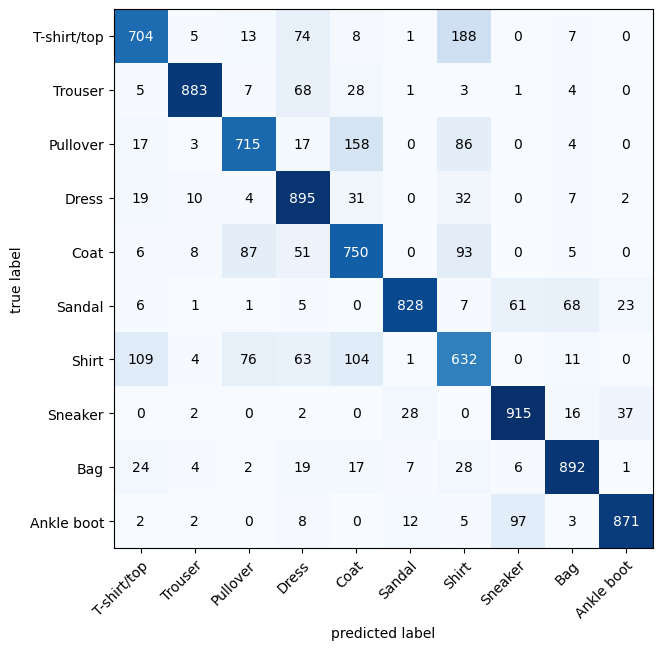

In [67]:
plot_confusion_matrix(confmat_tensor.numpy(), class_names=class_names, figsize=(10, 7))

In [72]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "pytorch_cv_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model2.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models\pytorch_cv_model_2.pth


In [73]:
model2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.1341, -0.6768,  0.2782],
                        [-0.5400, -0.6611, -0.3601],
                        [-0.1785, -0.8280, -0.7142]]],
              
              
                      [[[ 0.0650, -0.2751,  0.1250],
                        [ 0.4628, -0.1252,  0.3291],
                        [-0.0484,  0.1546, -0.0540]]],
              
              
                      [[[ 0.1589, -0.3371,  0.0482],
                        [ 0.6859, -0.0319, -0.6903],
                        [ 0.2358, -0.2016, -0.3457]]],
              
              
                      [[[ 0.1030,  0.2866,  0.3133],
                        [ 0.0701, -0.2451,  0.2113],
                        [ 0.2146, -0.5951, -0.1205]]],
              
              
                      [[[ 0.2111,  0.3629,  0.4627],
                        [-0.1735, -0.3816,  0.1158],
                        [-0.7207, -0.6833, -0.0615]]],
              
              
      

In [79]:
# Create a new instance
loaded_m2 = FashionMNISTv2(input_shape=1, out_shape=len(class_names), hidden_units=10)

# Load in the saved weights
loaded_m2.load_state_dict(torch.load(f=MODEL_SAVE_PATH, weights_only=True))
loaded_m2.to(device)

FashionMNISTv2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [80]:
model2_results

{'model_name': 'FashionMNISTv2',
 'model_loss': 0.3320904913337562,
 'model_acc': 0.8766972843450479}

In [83]:
loaded_m2_results = eval_model(
    model=loaded_m2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    acc_fn=acc_fn,
    device=device
)
loaded_m2_results

{'model_name': 'FashionMNISTv2',
 'model_loss': 0.3320904913337562,
 'model_acc': 0.8766972843450479}

In [85]:
torch.isclose(
    torch.tensor(model2_results["model_loss"]),
    torch.tensor(loaded_m2_results["model_loss"]),
    atol=1e-02
)

tensor(True)